In [1]:
import matplotlib.pyplot as plt

from motion_planning.medial_axis import MedialAxisRRT, MedialAxisPRM
from motion_planning.space import PointRobot, PolygonalRobot
from motion_planning.obstacle_sets import BiasedPassage, RandomSamplePassage
from motion_planning.circle_approximation import ApproximationSpace

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

In [3]:
start, target = env.sample_task()

In [4]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


In [5]:
rrt = MedialAxisRRT(env)
path = rrt.search(start=start, target=target, max_steps=10000, goal_bias=0.1)

(15, 3) (1, 3201, 3)
Num MedialAxis Points: 209
Search Time: 8.852293968200684, Collision Checks: 8411


/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


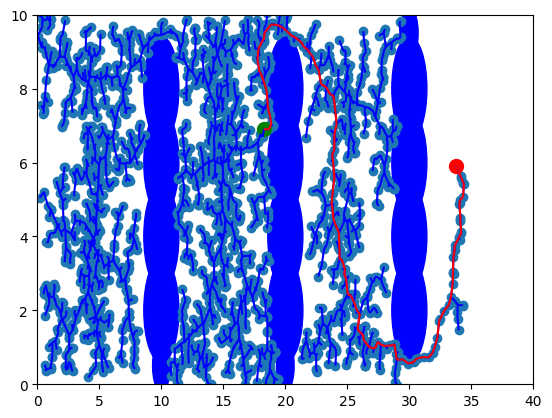

In [7]:
rrt.draw_tree(plt.gca(), path=path)

In [23]:
prm = MedialAxisPRM(env, num_samples=750, num_neighbors=5)
prm.create_graph()

(15, 3) (1, 3203, 3)
Num MedialAxis Points: 210
Connecting Edges Using knn strategy


/Users/pravaltelagi/motion_planning/motion_planning/utils.py:105: RuntimeWarning: invalid value encountered in divide
  normalized_gradients = gradients / lengths.reshape(-1, 1) # TODO: Probably need to reshape # (B, d)


In [24]:
path = prm.search(start=start, target=target)

In [30]:
print(start.value, target.value)

[18.28123952  6.90180654] [33.77533587  5.89894924]


In [29]:
for state in path:
    print(state.value)

[29.19354839  0.48780488]
[29.83870968  0.48780488]
[30.46469583  0.56385088]
[31.64213897  0.66768654]
[31.93359272  0.97665588]
[32.24443511  1.72179959]
[32.57079635  2.69171897]
[32.8907559   3.56868203]
[33.27749903  4.51907724]
[33.76169511  5.3180992 ]
[33.77533587  5.89894924]


/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


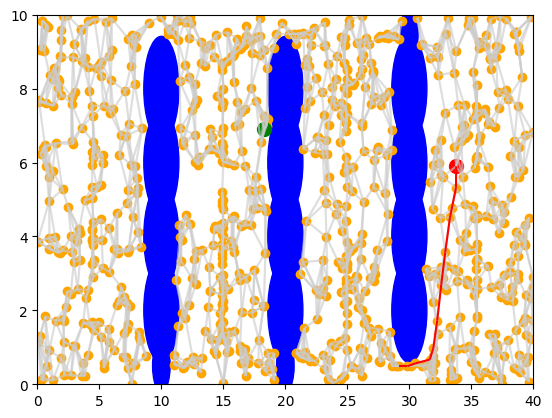

In [ ]:
env.draw_environment(plt.gca())
prm.draw(plt.gca(), path=path, show_task=True)